<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Beam on Elastic foundation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


In [32]:
# Define parameters and initial conditions
L = 10.0  # Length of the beam
EI = 5 * 10**6  # Flexural rigidity
k = 1 * 10**5  # Foundation modulus
dx = 0.01
x = torch.arange(0, L + dx, dx).to(device)

q0 = 1000.0  # Magnitude of the point load
p = q0 * torch.sin(torch.pi * x / L)  # Load distribution

In [39]:
def beam_on_elastic_foundation(EI, k, p, x):
    """Compute the deflection of a beam on an elastic foundation using finite difference method."""
    N = len(x)-1
    dx = x[1] - x[0]
    
    C = EI / dx**4

    A = torch.zeros((N+1, N+1)).to(device)
    b = p  # p supplied

    # interior nodes i=2..N-2
    for i in range(2, N-1):
        A[i, i-2] = C
        A[i, i-1] = -4*C
        A[i, i]   = 6*C + k
        A[i, i+1] = -4*C
        A[i, i+2] = C

    # i = 1 (use ghost elimination w_{-1} = -w1 since w0=0)
    A[1, 1] = 5*C + k
    A[1, 2] = -4*C
    A[1, 3] = C

    # i = N-1 (symmetric)
    A[N-1, N-3] = C
    A[N-1, N-2] = -4*C
    A[N-1, N-1] = 5*C + k

    # BC rows
    A[0, :] = 0; A[0, 0] = 1; b[0] = 0
    A[N, :] = 0; A[N, N] = 1; b[N] = 0
    w = torch.linalg.solve(A, b)
    return w

=== WAVE DATA GENERATION ===
Generated 2000 polynomial functions
Coefficient shape: torch.Size([2000, 2]) (q, n for q * sin(n * πx / L))
Spatial domain: x ∈ [0.0, 10.0] with 100 points
Functions shape: torch.Size([2000, 100])
Derivatives shape: torch.Size([2000, 100])


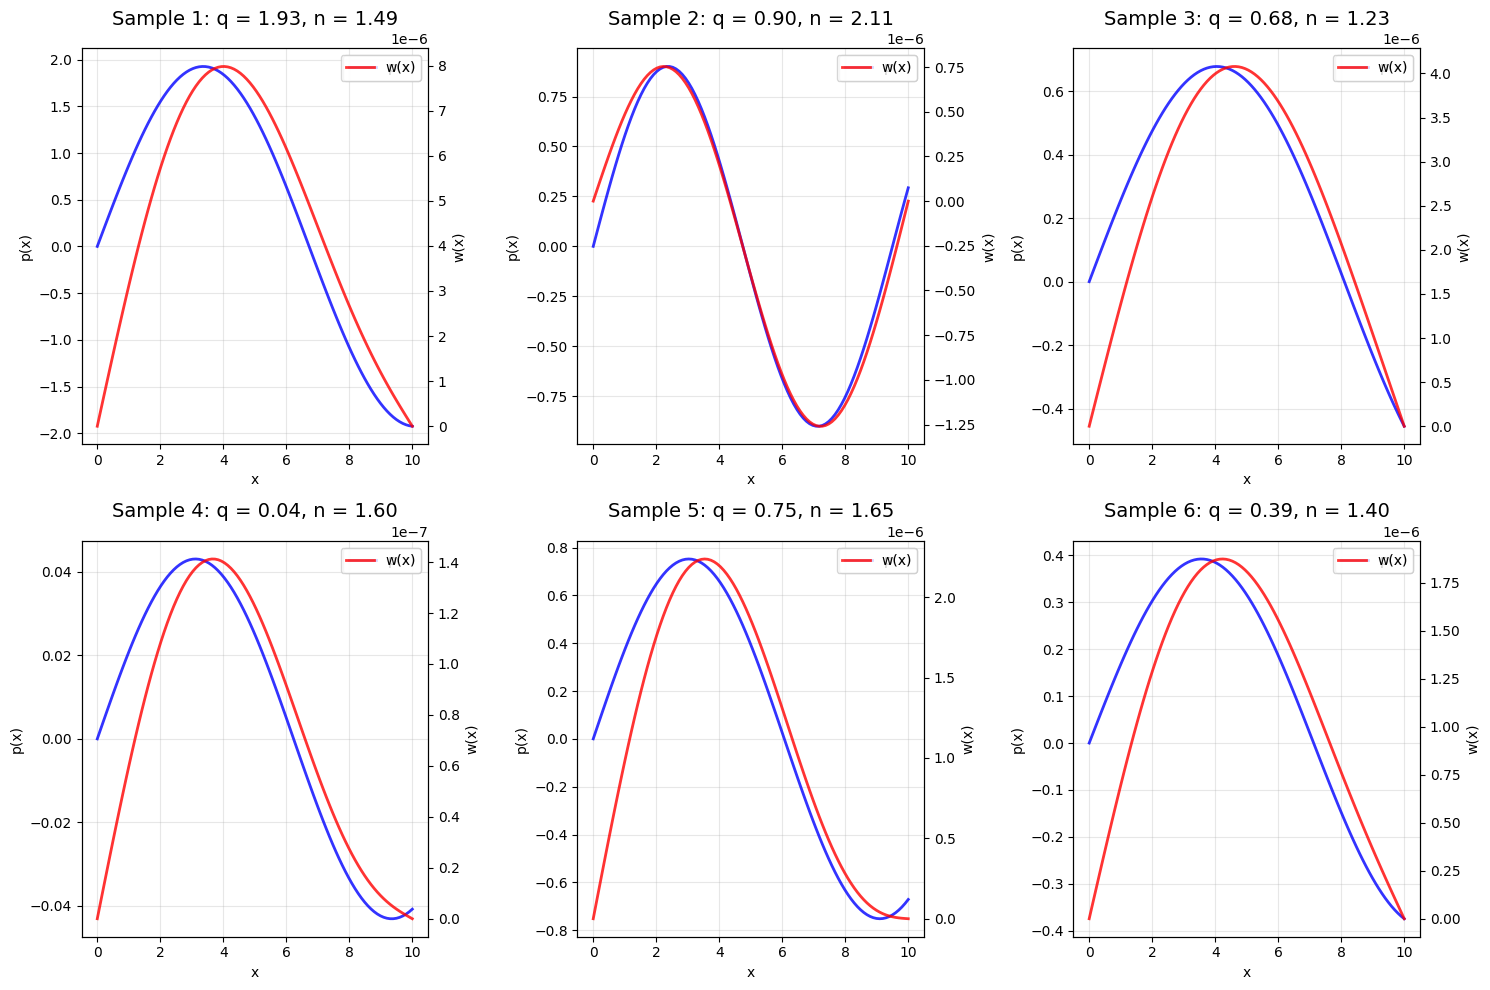


Mathematical relationships:
p(x) = q * sin(n * πx / L)
w(x) = FD_solution(EI, k, p(x))
Goal: Learn operator mapping (q, n) → w(x)


In [79]:
# ========================= CELL 1: Data Generation =========================
def generate_wave_data(num_functions=2000, num_points=100, x_range=(0, 10)):
    """Generate cubic polynomial functions and their derivatives"""
    torch.random.manual_seed(42)
    
    # Generate random coefficients for cubic polynomials: ax^3 + bx^2 + cx + d
    coeffs = torch.abs(torch.randn(num_functions, 2)).to(device)  # Scale coefficients for variability

    # Generate x values
    x = torch.linspace(x_range[0], x_range[1], num_points).to(device)

    # Initialize tensors to hold load and waveform data
    loads = torch.zeros((num_functions, num_points)).to(device)
    waveforms = torch.zeros((num_functions, num_points)).to(device)

    for i in range(num_functions):
        q, n = coeffs[i]
        # Define the polynomial load function
        load = q * torch.sin(n *torch.pi * x / L).to(device)
        loads[i, :] = load

        # Compute the waveform (deflection) using finite difference method
        waveform = beam_on_elastic_foundation(EI, k, load, x)
        waveforms[i, :] = waveform

    return coeffs, x, loads, waveforms

print("=== WAVE DATA GENERATION ===")
coeffs, x, loads, waveforms = generate_wave_data()
print(f"Generated {len(coeffs)} polynomial functions")
print(f"Coefficient shape: {coeffs.shape} (q, n for q * sin(n * πx / L))")
print(f"Spatial domain: x ∈ [{x[0]:.1f}, {x[-1]:.1f}] with {len(x)} points")
print(f"Functions shape: {loads.shape}")
print(f"Derivatives shape: {waveforms.shape}")


# Visualize sample polynomials and their derivatives
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i in range(6):
    ax = axes[i//3, i%3]
    
    # Plot function and derivative
    ax.plot(x.cpu().numpy(), loads.cpu().numpy()[i], 'b-', linewidth=2, label=f'p(x)', alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(x.cpu().numpy(), waveforms.cpu().numpy()[i], 'r-', linewidth=2, label=f"w(x)", alpha=0.8)
    
    # Show coefficients
    q, n = coeffs[i].cpu().numpy()
    ax.set_title(f'Sample {i+1}: q = {q:.2f}, n = {n:.2f}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('p(x)')

    ax2.set_ylabel('w(x)')
    ax2.legend(loc='upper right')
    
plt.tight_layout()
plt.savefig('polynomial_samples.png', dpi=150)
plt.show()

# Print some mathematical relationships
print("\nMathematical relationships:")
print("p(x) = q * sin(n * πx / L)")
print("w(x) = FD_solution(EI, k, p(x))")
print("Goal: Learn operator mapping (q, n) → w(x)")

In [80]:
class DeepONet(nn.Module):
    def __init__(self, branch_input_dim, trunk_input_dim, hidden_dim=32, num_basis=3):
        super(DeepONet, self).__init__()
        self.num_basis = num_basis
        self.hidden_dim = hidden_dim
        
        # Branch network - processes function coefficients
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_basis)
        )
        
        # Trunk network - processes spatial coordinates
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_basis)
        )
        
        # Bias term
        self.bias = nn.Parameter(torch.zeros(1))
        
    def forward(self, branch_input, trunk_input):
        # Branch network output
        branch_out = self.branch_net(branch_input)  # [batch_size, num_basis]
        
        # Trunk network output - handle batch dimension
        if trunk_input.dim() == 3:  # [batch_size, num_points, 1]
            batch_size, num_points, _ = trunk_input.shape
            trunk_input_flat = trunk_input.view(-1, 1)  # [batch_size * num_points, 1]
            trunk_out = self.trunk_net(trunk_input_flat)  # [batch_size * num_points, num_basis]
            trunk_out = trunk_out.view(batch_size, num_points, self.num_basis)  # [batch_size, num_points, num_basis]
        else:  # [num_points, 1] - single evaluation
            trunk_out = self.trunk_net(trunk_input)  # [num_points, num_basis]
            trunk_out = trunk_out.unsqueeze(0)  # [1, num_points, num_basis]
        
        # Compute inner product
        output = torch.einsum('bi,bpi->bp', branch_out, trunk_out)
        
        return output + self.bias


print("\n=== DEEPONET ARCHITECTURE ===")
model = DeepONet(branch_input_dim=2, trunk_input_dim=1, hidden_dim=32, num_basis=3)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"DeepONet Architecture:")
print(f"- Branch input: 2 (polynomial coefficients [q,n])")
print(f"- Trunk input: 1 (spatial coordinate x)")
print(f"- Hidden dimension: {model.hidden_dim}")
print(f"- Number of basis functions: {model.num_basis}")
print(f"- Total parameters: {total_params:,}")
print(f"- Trainable parameters: {trainable_params:,}")


=== DEEPONET ARCHITECTURE ===
DeepONet Architecture:
- Branch input: 2 (polynomial coefficients [q,n])
- Trunk input: 1 (spatial coordinate x)
- Hidden dimension: 32
- Number of basis functions: 3
- Total parameters: 359
- Trainable parameters: 359


C:\Users\emman\AppData\Local\Temp\ipykernel_61308\1635390095.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
C:\Users\emman\AppData\Local\Temp\ipykernel_61308\1635390095.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(train_coeffs, dtype=torch.float32),
C:\Users\emman\AppData\Local\Temp\ipykernel_61308\1635390095.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(train_waveforms, dtype=torch.float32)
C:\Users\emman\AppData\Local\Temp\ipykern


=== TRAINING ===
Data splits:
- Training batches: 13 (batch size: 128)
- Validation batches: 2
- Test samples: 200
\nStarting training...


Training DeepONet:  86%|████████▌ | 430/500 [00:13<00:02, 32.04it/s, Train=0.000000, Val=0.000000, LR=0.005000]


\nEarly stopping at epoch 430


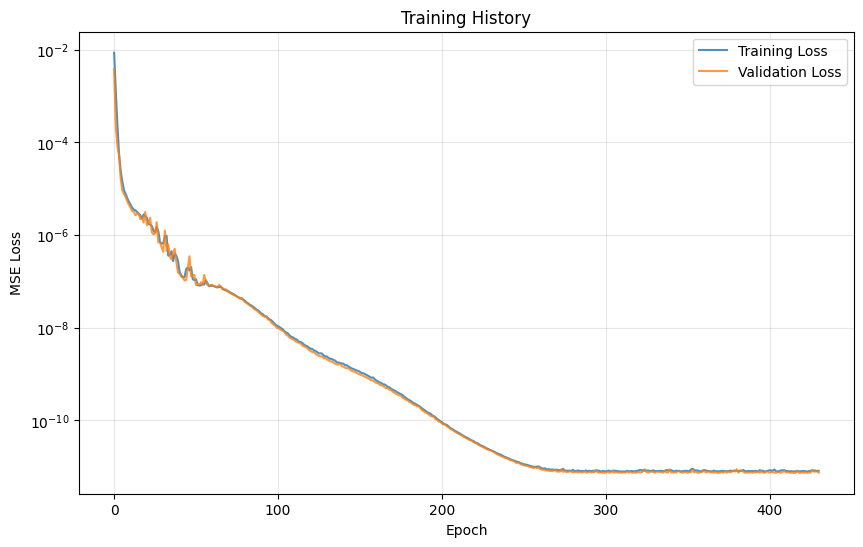

Training completed!
Final training loss: 0.000000
Final validation loss: 0.000000


In [81]:
def setup_data_loaders(coeffs, x, waveforms, batch_size=128):
    """Setup train/val/test data loaders"""
    # Split data
    train_size = int(0.8 * len(coeffs))
    val_size = int(0.1 * len(coeffs))
    
    train_coeffs = coeffs[:train_size]
    train_waveforms = waveforms[:train_size]
    
    val_coeffs = coeffs[train_size:train_size+val_size]
    val_waveforms = waveforms[train_size:train_size+val_size]
    
    test_coeffs = coeffs[train_size+val_size:]
    test_waveforms = waveforms[train_size+val_size:]
    
    # Convert to tensors
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
    
    # Create datasets - expand x_tensor for each function
    train_x = x_tensor.unsqueeze(0).repeat(len(train_coeffs), 1, 1)
    val_x = x_tensor.unsqueeze(0).repeat(len(val_coeffs), 1, 1)
    
    train_dataset = TensorDataset(
        torch.tensor(train_coeffs, dtype=torch.float32),
        train_x,
        torch.tensor(train_waveforms, dtype=torch.float32)
    )
    
    val_dataset = TensorDataset(
        torch.tensor(val_coeffs, dtype=torch.float32),
        val_x,
        torch.tensor(val_waveforms, dtype=torch.float32)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, (test_coeffs, test_waveforms)

def train_deeponet(model, train_loader, val_loader, num_epochs=500, lr=0.01):
    """Train the DeepONet model"""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    patience = 100
    patience_counter = 0
    
    # Progress bar
    pbar = tqdm(range(num_epochs), desc="Training DeepONet")
    
    for epoch in pbar:
        # Training
        model.train()
        train_loss = 0.0
        for batch_coeffs, batch_x, batch_waveforms in train_loader:
            batch_coeffs = batch_coeffs.to(device)
            batch_x = batch_x.to(device)
            batch_waveforms = batch_waveforms.to(device)
            
            optimizer.zero_grad()
            output = model(batch_coeffs, batch_x)
            loss = criterion(output, batch_waveforms)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_coeffs, batch_x, batch_waveforms in val_loader:
                batch_coeffs = batch_coeffs.to(device)
                batch_x = batch_x.to(device)
                batch_waveforms = batch_waveforms.to(device)
                
                output = model(batch_coeffs, batch_x)
                loss = criterion(output, batch_waveforms)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        # Update progress bar
        pbar.set_postfix({
            'Train': f'{avg_train_loss:.6f}',
            'Val': f'{avg_val_loss:.6f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
        })
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\\nEarly stopping at epoch {epoch}')
                break
    
    pbar.close()
    return train_losses, val_losses

print("\n=== TRAINING ===")
train_loader, val_loader, test_data = setup_data_loaders(coeffs, x, waveforms, batch_size=128)

print(f"Data splits:")
print(f"- Training batches: {len(train_loader)} (batch size: 128)")
print(f"- Validation batches: {len(val_loader)}")
print(f"- Test samples: {len(test_data[0])}")

print("\\nStarting training...")
train_losses, val_losses = train_deeponet(model, train_loader, val_loader, num_epochs=500, lr=0.01)

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.8)
plt.plot(val_losses, label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Training completed!")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")


=== PREDICTION & EVALUATION ===
Average Test MSE: 0.000000
Test MSE std: 0.000000


C:\Users\emman\AppData\Local\Temp\ipykernel_61308\2654758234.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coeffs_tensor = torch.tensor(test_coeffs[i:i+1], dtype=torch.float32).to(device)
C:\Users\emman\AppData\Local\Temp\ipykernel_61308\2654758234.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)


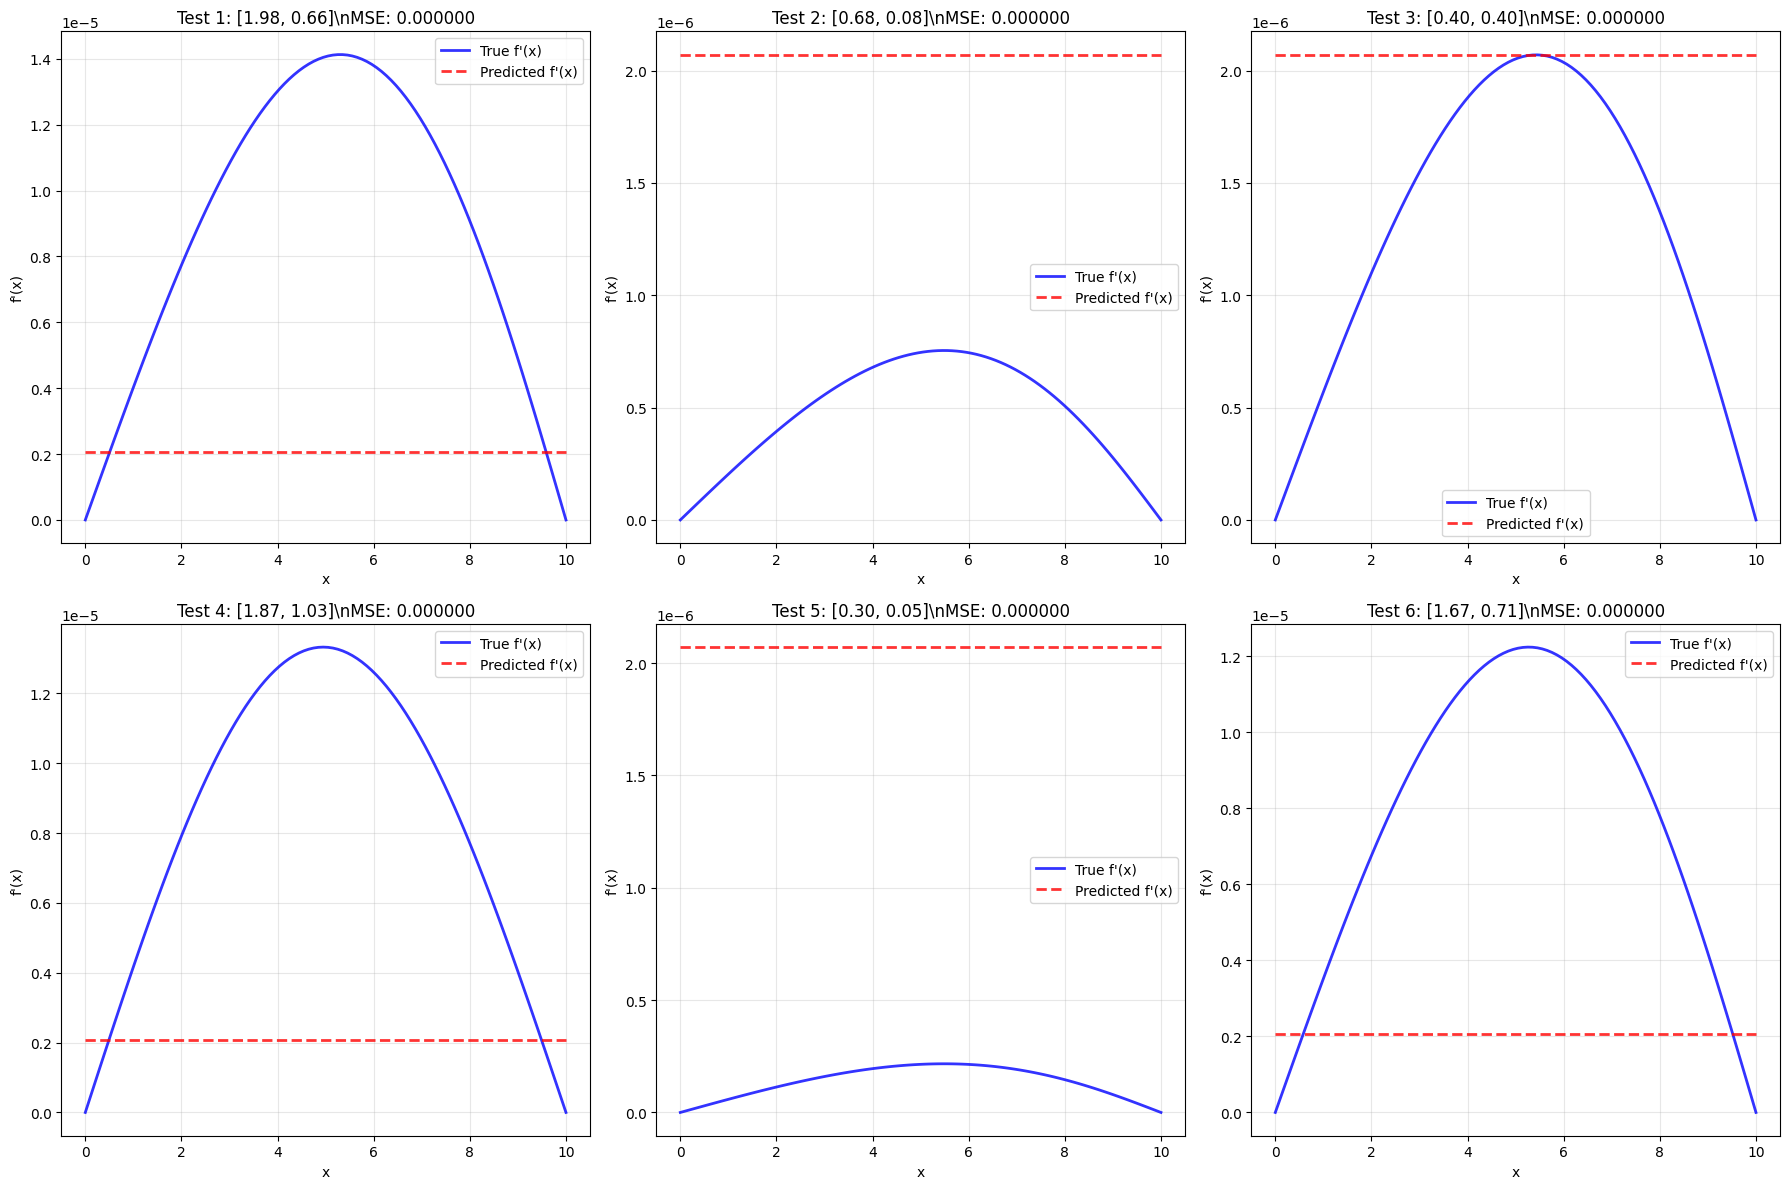

In [82]:
def evaluate_predictions(model, test_data, x):
    """Evaluate model predictions and create visualizations"""
    test_coeffs, test_waveforms = test_data
    model.eval()
    
    # Compute test errors
    test_errors = []
    predictions = []
    
    with torch.no_grad():
        for i in range(len(test_coeffs)):
            coeffs_tensor = torch.tensor(test_coeffs[i:i+1], dtype=torch.float32).to(device)
            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
            
            predicted = model(coeffs_tensor, x_tensor).cpu().numpy().flatten()
            true_waveform = test_waveforms[i].cpu().numpy()
            
            mse = np.mean((predicted - true_waveform)**2)
            test_errors.append(mse)
            predictions.append(predicted)
    
    avg_test_mse = np.mean(test_errors)
    print(f"Average Test MSE: {avg_test_mse:.6f}")
    print(f"Test MSE std: {np.std(test_errors):.6f}")
    
    return predictions, test_errors

print("\n=== PREDICTION & EVALUATION ===")
predictions, test_errors = evaluate_predictions(model, test_data, x)
test_coeffs, test_waveforms = test_data

# Plot prediction results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot sample predictions
for i in range(6):
    ax = axes[i//3, i%3]
    
    ax.plot(x.cpu().numpy(), test_waveforms[i].cpu().numpy(), 'b-', linewidth=2, label='True f\'(x)', alpha=0.8)
    ax.plot(x.cpu().numpy(), predictions[i], 'r--', linewidth=2, label='Predicted f\'(x)', alpha=0.8)
    
    # Show coefficients and error
    coeffs_str = ', '.join([f'{c:.2f}' for c in test_coeffs[i]])
    error = test_errors[i]
    ax.set_title(f'Test {i+1}: [{coeffs_str}]\\nMSE: {error:.6f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel("f'(x)")

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150)
plt.show()


In [17]:
start_exact = time.time()
w_exact = (q0 * np.sin(np.pi * x / L)) / (k + (EI * (np.pi / L)**4))
end_exact = time.time()

In [18]:
print(f"Computation Time: {end_fd - start_fd:.4f} seconds")
print(f"Computation Time (Exact): {end_exact - start_exact:.4f} seconds")

Computation Time: 0.2354 seconds
Computation Time (Exact): 0.0000 seconds


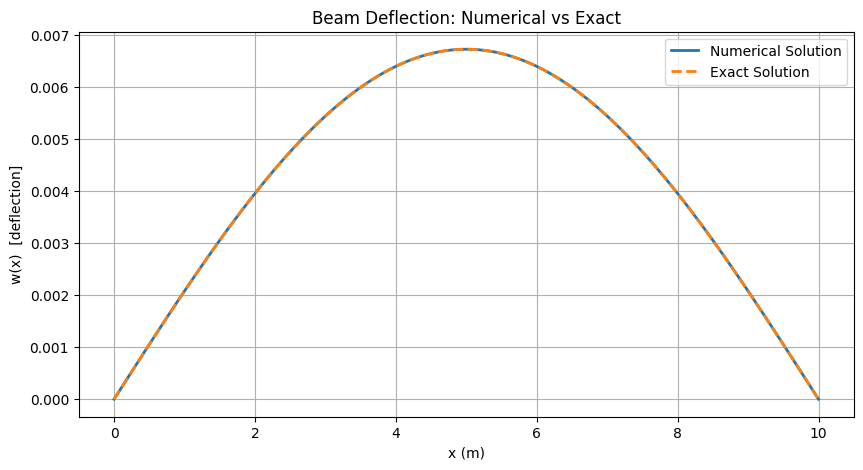

In [19]:
# Comparison of finite difference and exact solution
plt.figure(figsize=(10,5))

plt.plot(x, w, label='Numerical Solution', linewidth=2)
plt.plot(x, w_exact, '--', label='Exact Solution', linewidth=2)

plt.xlabel("x (m)")
plt.ylabel("w(x)  [deflection]")
plt.title("Beam Deflection: Numerical vs Exact")

plt.legend()
plt.grid(True)

plt.show()

## Executive summary

In [21]:
print(f"Computation Time (FD): {end_fd - start_fd:.4f} seconds")
print(f"Computation Time (Exact): {end_exact - start_exact:.4f} seconds")

Computation Time (FD): 0.2354 seconds
Computation Time (Exact): 0.0000 seconds
